Implementación computacional de un sistema hamiltoniano con acople electromagnético sin y con transformación de Gauge utilizando un integrador de punto medio simpléctico.

Modelo: Campo magnético $\vec{B} = (0,0,B_{0}) = \nabla\times \vec{A}$, con $\vec{A}=\frac{B_{0}}{2}(-y,x,0)$, y $A'=A+\nabla\left(\frac{B_{0}}{2}xy\right)=B_{0}(0,x,0)$ 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

In [15]:
# Parámetros del sistema físico
m = 1.0
e = 1.0
c = 1.0
B0 = 1.0
alpha = e*B0/(2*m)

# Parámetros de simulación del sistema
t_span = (0,100)
# Modificar el paso n_pasos=h
n_pasos= 100000

# Condiciones iniciales (Caso sin Gauge)
Coninit = np.array([1.0, 0.0, 0.0, 0.0, 1.0, 1.0]) 

# Se deben cambiar las condiciones iniciales para el cambio de Gauge, P_gauge = P_no + e/c (A_gauge - A_no) = eB0/2c (y,x,0)
init_Gauge = Coninit + [0.0, 0.0, 0.0, alpha*Coninit[1], alpha*Coninit[0], 0.0]

Modelo Sin Gauge, usando $\vec{A}=\frac{B_{0}}{2}(-y,x,0)$.

$H(q,p)=\frac{1}{2m}\left(\left(P_{x}+\frac{eB_{0}}{2c}y\right)^{2} + \left(p_{y}-\frac{eB_{0}}{2c}x\right)^{2} + p_{z}^{2}\right)$.

In [16]:
def Hamiltoniano_noGauge(estado):  #Hamiltoniano (Energía)
    x,y,z,px,py,pz = estado
    alpha = e*B0/(2*c)
    return ((px + alpha*y)**2 + (py - alpha*x)**2 + pz**2)/(2*m) 

def f_noGauge(estado): #Ecuaciones de Hamilton
    x,y,z,px,py,pz = estado
    alpha = e*B0/(2*c)
    dx = (px + alpha*y)/m
    dy = (py - alpha*x)/m
    dz = pz/m
    dpx = alpha*(py - alpha*x)/m
    dpy = -alpha*(px + alpha*y)/m
    dpz = 0.0
    return np.array([dx,dy,dz,dpx,dpy,dpz])

def paso_midpoint_noGauge(estado, h, tol=1e-10, max_iter=20):
    
    y_next = estado + h * f_noGauge(estado)
    
    for _ in range(max_iter):
        # Punto medio entre estado actual y el estimado
        y_mid = (estado + y_next) / 2
        f_mid = f_noGauge(y_mid)
        y_new = estado + h * f_mid
        if np.linalg.norm(y_new - y_next) < tol:
            return y_new
        
        y_next = y_new
    
    return y_next

def int_midpoint_noGauge(init, t_span, n_pasos):
    t0, tf = t_span
    h = (tf-t0)/n_pasos
    t_puntos = np.linspace(t0, tf, n_pasos+1)
    estados = np.zeros((n_pasos+1, 6))
    energias = np.zeros(n_pasos+1)
    
    estados[0] = init
    energias[0] = Hamiltoniano_noGauge(init)
    
    for i in range(n_pasos):
        estados[i+1] = paso_midpoint_noGauge(estados[i], h)
        energias[i+1] = Hamiltoniano_noGauge(estados[i+1])
    
    return t_puntos, estados, energias

Modelo con Gauge $A'=B_{0}(0,x,0)$

$H(q,p)=\frac{1}{2m}\left(p_{x}^{2} + (p_{y}- \frac{e}{c}B_{0}x)^{2}+p_{z}^{2}\right)$

In [17]:
def Hamiltoniano_Gauge(estado):  #Hamiltoniano (Energía)
    x, y, z, px, py, pz = estado
    beta = e*B0/c
    return (px**2 + (py-beta*x)**2 + pz**2)/(2*m)

def f_Gauge(estado):  #Ecuaciones de Hamilton
    x, y, z, px, py, pz = estado
    beta = e*B0/c
    dx = px/m
    dy = (py - beta*x)/m
    dz = pz/m
    dpx = beta*(py - beta*x)/m
    dpy = 0.0
    dpz = 0.0
    return np.array([dx,dy,dz,dpx,dpy,dpz])


def paso_midpoint_Gauge(estado, h, tol=1e-10, max_iter=20):
    
    y_next = estado + h * f_Gauge(estado)
    
    for _ in range(max_iter):
        
        y_mid = (estado + y_next) / 2
        f_mid = f_Gauge(y_mid)
        y_new = estado + h * f_mid
        if np.linalg.norm(y_new - y_next) < tol:
            return y_new
        
        y_next = y_new
    
    return y_next

def int_midpoint_Gauge(init, t_span, n_pasos):
    t0, tf = t_span
    h = (tf-t0)/n_pasos
    t_puntos = np.linspace(t0,tf,n_pasos+1)
    estados = np.zeros((n_pasos+1,6))
    energias = np.zeros(n_pasos+1)
    estados[0] = init
    energias[0] = Hamiltoniano_Gauge(init)
    for i in range(n_pasos):
        estados[i+1] = paso_midpoint_Gauge(estados[i], h)
        energias[i+1] = Hamiltoniano_Gauge(estados[i+1])
    return t_puntos, estados, energias

In [18]:
t1,estados1,E1 = int_midpoint_noGauge(Coninit,t_span, n_pasos)
t2,estados2,E2 = int_midpoint_Gauge(init_Gauge,t_span, n_pasos)

In [19]:
# ERROR: Esto te da 10⁻¹ si E1 ≈ 1 y diff ≈ 0.1
error1 = np.abs((E1 - E1[0]) / E1[0])

# CORRECTO: Asegúrate que E1[0] no sea cero
# Si H(0) ≈ 1, entonces error ≈ 10⁻⁹ es correcto
print(f"H(0) = {E1[0]:.15f}")  # Verifica el valor inicial
print(f"Max error = {np.max(np.abs(E1 - E1[0])):.15f}")
print(f"Max error relativo = {np.max(np.abs((E1 - E1[0])/E1[0])):.15f}")

H(0) = 0.625000000000000
Max error = 0.000000000000010
Max error relativo = 0.000000000000016


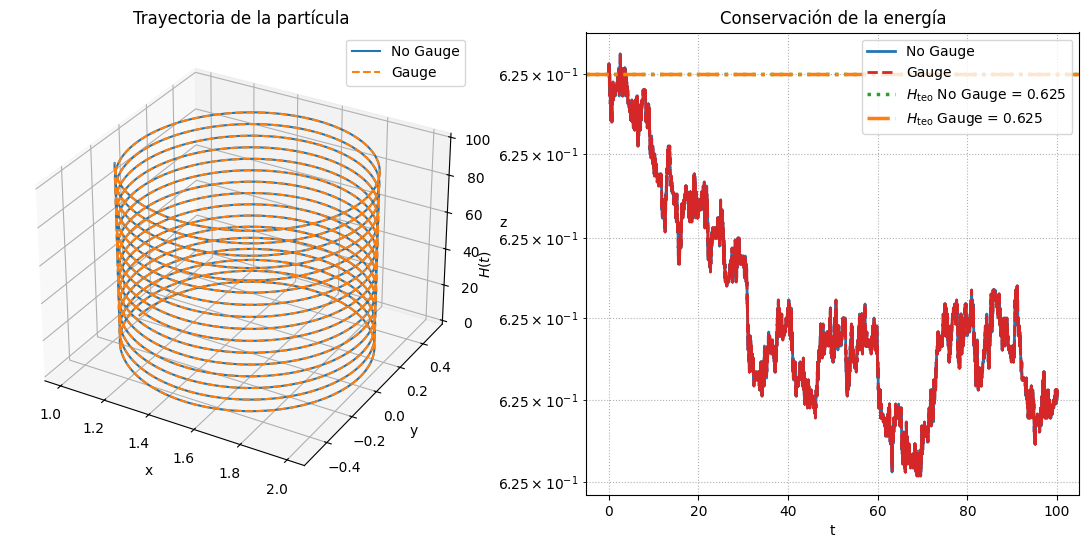

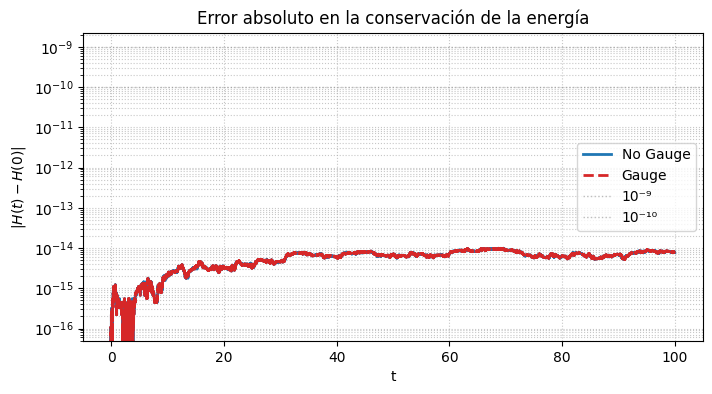

In [21]:
x1 , x2 = estados1[:,0] , estados2[:,0]
y1 , y2 = estados1[:,1] , estados2[:,1]
z1 , z2 = estados1[:,2] , estados2[:,2]

fig = plt.figure(figsize=(14,6))

# Curvas en 3D
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot(x1, y1, z1, label='No Gauge')
ax1.plot(x2, y2, z2, '--', label='Gauge')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('z')
ax1.set_title('Trayectoria de la partícula')
ax1.legend()


ax2 = fig.add_subplot(122)
ax2.semilogy(t1, E1, color='tab:blue', linestyle='-', linewidth=2, label='No Gauge')
ax2.semilogy(t2, E2, color='tab:red', linestyle='--', linewidth=2, label='Gauge')
ax2.axhline(E1[0], color='tab:green',  linestyle=':', linewidth=2.5, label=fr'$H_{{\rm teo}}$ No Gauge = {E1[0]:.3f}')
ax2.axhline(E2[0], color='tab:orange',linestyle='-.', linewidth=2.5, label=fr'$H_{{\rm teo}}$ Gauge = {E2[0]:.3f}')
ax2.set_xlabel('t')
ax2.set_ylabel(r'$H(t)$')
ax2.set_title('Conservación de la energía')
ax2.grid(True, which='both', linestyle=':')
ax2.legend()


fig, ax2 = plt.subplots(figsize=(8, 4))
diff1 = np.abs(E1 - E1[0])
diff2 = np.abs(E2 - E2[0])
ax2.semilogy(t1, diff1, color='tab:blue', linestyle='-', linewidth=2, label='No Gauge')
ax2.semilogy(t2, diff2, color='tab:red', linestyle='--', linewidth=2, label='Gauge')
ax2.axhline(1e-9, color='gray', linestyle=':', linewidth=1, alpha=0.5, label='10⁻⁹')
ax2.axhline(1e-10, color='gray', linestyle=':', linewidth=1, alpha=0.5, label='10⁻¹⁰')
ax2.set_xlabel('t')
ax2.set_ylabel(r'$|H(t) - H(0)|$')
ax2.set_title('Error absoluto en la conservación de la energía')
ax2.grid(True, which='both', linestyle=':', alpha=0.7)
ax2.legend()

plt.show()